In [ ]:
import pandas as pd
df=pd.read_csv("Loan.csv")
print(df.head())

    Loan_ID Gender Married Dependents Education Self_Employed  \
0  LP001002   Male      No          0  Graduate            No   
1  LP001003   Male     Yes          1  Graduate            No   
2  LP001005   Male     Yes          0  Graduate           Yes   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0         Urban           Y  


In [2]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [9]:
df.rename(columns={
    "Sex": "Gender"
})

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [17]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
609    False
610    False
611    False
612    False
613    False
Length: 614, dtype: bool

In [18]:
df['Gender'] = df['Gender'].fillna("Male")

In [19]:
df['Married'] = df['Married'].fillna("Yes")

In [20]:
df['Dependents'] = df['Dependents'].fillna(0)

In [34]:
df['Self_Employed'] = df['Self_Employed'].fillna("Yes")

In [33]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())

In [36]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())

In [35]:

df['Credit_History'] = df['Credit_History'].fillna(1.0)

In [37]:
df.isnull().sum()

Loan_ID                   0
Gender                    0
Married                   0
Dependents                0
Education                 0
Self_Employed             0
ApplicantIncome           0
CoapplicantIncome         0
LoanAmount                0
Loan_Amount_Term          0
Credit_History            0
Property_Area             0
Loan_Status               0
ApplicantIncome_capped    0
dtype: int64

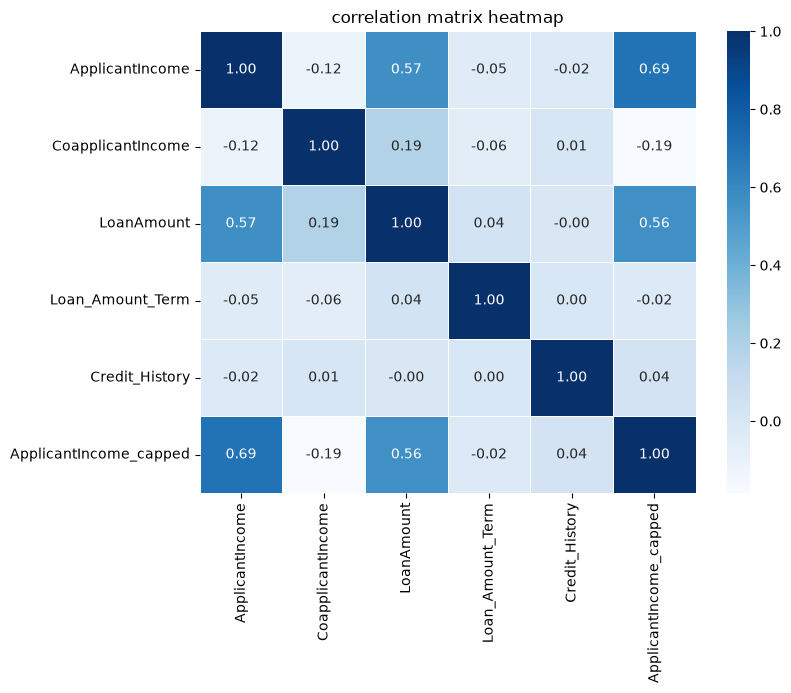

In [38]:
import  matplotlib.pyplot as plt
import seaborn as sns
corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)
plt.title("correlation matrix heatmap")
plt.show()


In [39]:
q1=df['ApplicantIncome'].quantile(0.25)
q3=df["ApplicantIncome"].quantile(0.75)
IQR=q3-q1
lower_limit=q1-1.5*IQR
upper_limit=q3+1.5*IQR
print("q1:",q1)
print('q3:',q3)
print("IQR:",IQR)
print("lower_limit:",lower_limit)
print("upper_limit:",upper_limit)
outliers=df[
    (df["ApplicantIncome"]<lower_limit) |
    (df["ApplicantIncome"]>upper_limit)
]
print("\n ApplicantIncome Outliers:",len(outliers))
print("\n ApplicantIncome outliers:")
print(outliers[["Loan_ID","ApplicantIncome"]].head(20))

q1: 2877.5
q3: 5795.0
IQR: 2917.5
lower_limit: -1498.75
upper_limit: 10171.25

 ApplicantIncome Outliers: 50

 ApplicantIncome outliers:
      Loan_ID  ApplicantIncome
9    LP001020            12841
34   LP001100            12500
54   LP001186            11500
67   LP001233            10750
102  LP001350            13650
106  LP001369            11417
115  LP001401            14583
119  LP001422            10408
126  LP001448            23803
128  LP001451            10513
130  LP001469            20166
138  LP001492            14999
144  LP001508            11757
146  LP001516            14866
155  LP001536            39999
171  LP001585            51763
183  LP001637            33846
185  LP001640            39147
191  LP001656            12000
199  LP001673            11000


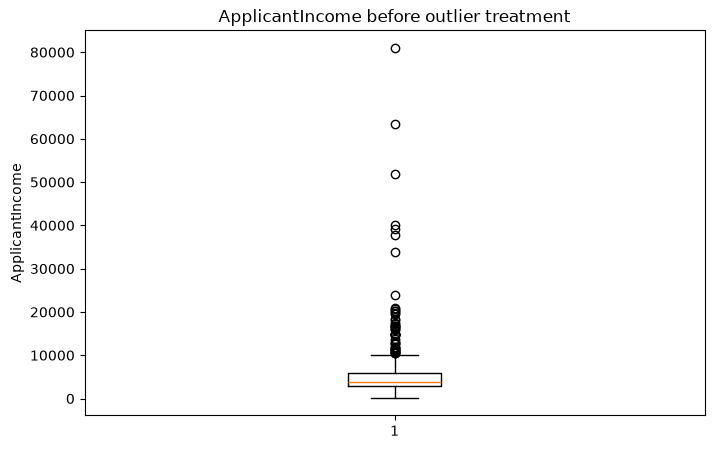

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.boxplot(df['ApplicantIncome'])
plt.title("ApplicantIncome before outlier treatment")
plt.ylabel("ApplicantIncome")
plt.show()

In [41]:
df["ApplicantIncome_capped"]=df["ApplicantIncome"].clip(
    lower=lower_limit,
    upper=upper_limit
)

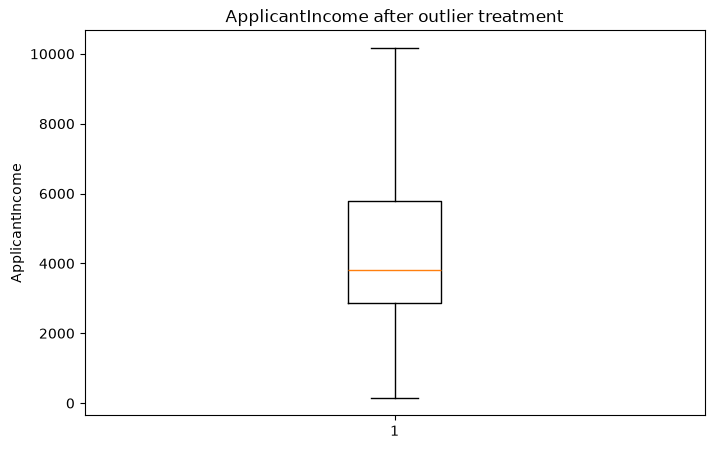

In [42]:
plt.figure(figsize=(8,5))
plt.boxplot(df['ApplicantIncome_capped'])
plt.title("ApplicantIncome after outlier treatment")
plt.ylabel("ApplicantIncome")
plt.show()

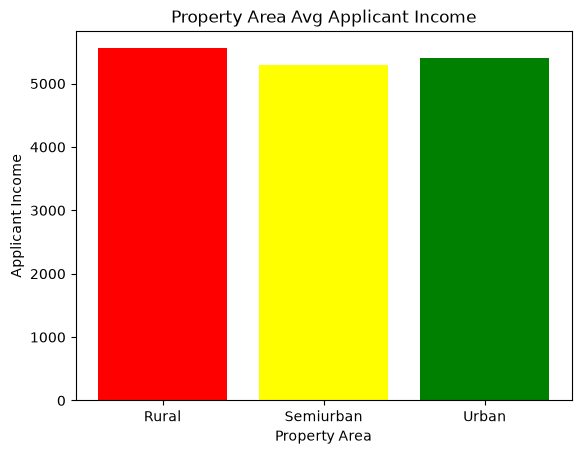

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
gender=df.groupby("Property_Area")["ApplicantIncome"].mean()
plt.bar(gender.index,
        gender.values,
        color=["red","yellow","green"]
        )
plt.title("Property Area Avg Applicant Income")
plt.xlabel("Property Area")
plt.ylabel("Applicant Income")
plt.show()


Average LoanAmount by Loan_Amount_Term:
Loan_Amount_Term
12.0     111.000000
36.0     117.500000
60.0     140.000000
84.0     132.250000
120.0     22.333333
180.0    147.473280
240.0    125.353041
300.0    185.153846
342.0    116.214286
360.0    147.214514
480.0    151.800000
Name: LoanAmount, dtype: float64


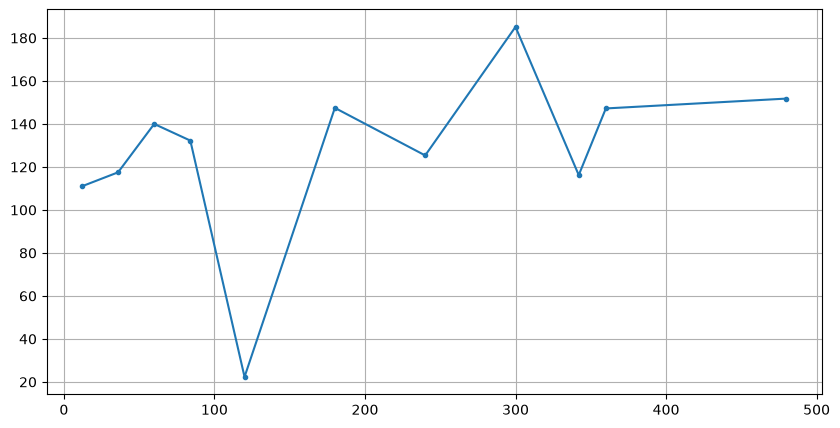

In [45]:
Loan_Amount_Term_vs_LoanAmount = df.groupby("Loan_Amount_Term")["LoanAmount"].mean()
print("\nAverage LoanAmount by Loan_Amount_Term:")
print(Loan_Amount_Term_vs_LoanAmount)
plt.figure(figsize=(10,5))
plt.plot(
    Loan_Amount_Term_vs_LoanAmount.index,
    Loan_Amount_Term_vs_LoanAmount.values,
    marker="."
)

plt.title = ("Average LoanAmount by Loan_Amount_Term ")
plt.xlabel = ("Loan_Amount_Term")
plt.ylabel = ("LoanAmount")
plt.grid(True)
plt.show()

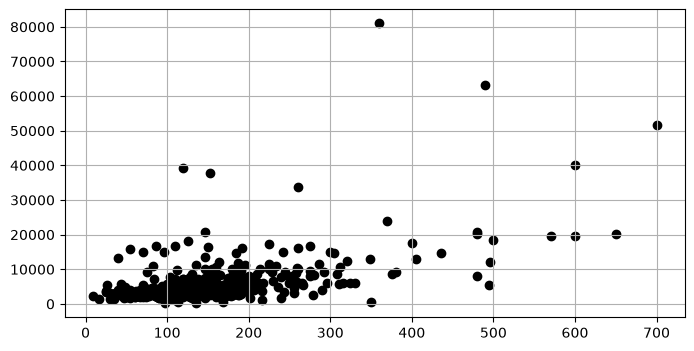

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.scatter(df["LoanAmount"], df["ApplicantIncome"], color="black")

plt.title = ("LoanAmount vs ApplicantIncome")
plt.xlabel = ("LoanAmount")
plt.ylabel = ("ApplicantIncome")
plt.grid(True)

plt.show()

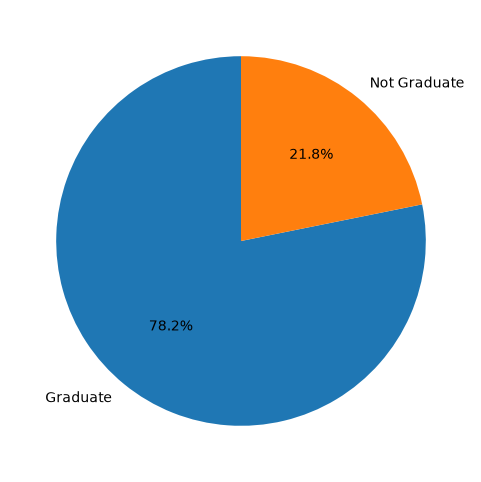

In [53]:
edu = df["Education"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(edu,
        labels=edu.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title = ("Education Distribution")
plt.show()

First 5 Rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0  146.412162             360.0   
1             4583             1508.0  128.000000             360.0   
2             3000                0.0   66.000000             360.0   
3             2583             2358.0  120.000000             360.0   
4             6000                0.0  141.000000             360.0   

   Credit_History Property_Area Loan_Status  ApplicantIncome_capped  
0             1.0         Urban           Y                  5849.0  
1   

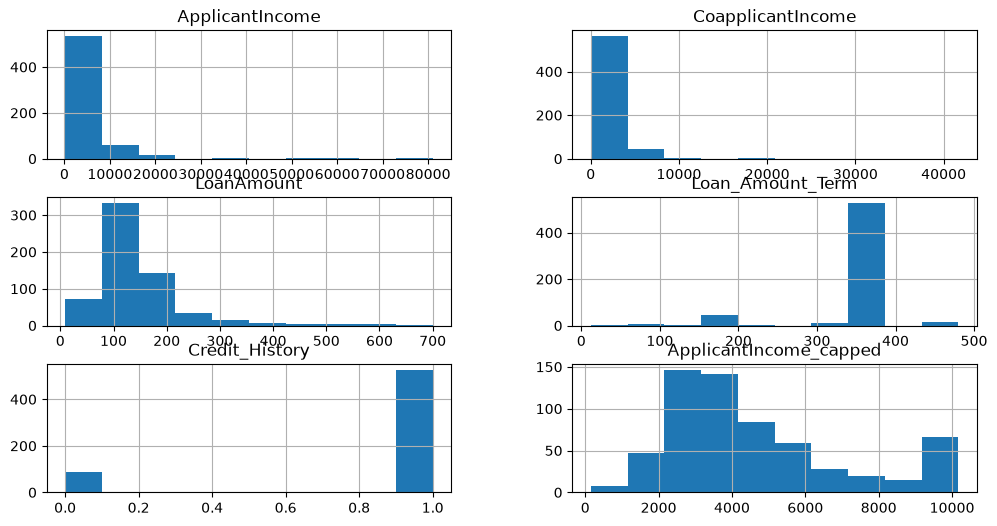

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("First 5 Rows:")
print(df.head())
print("\nLast 5 Rows:")
print(df.tail())
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nShape of Dataset:")
print(df.shape)
df.hist(figsize=(12,6))
plt.title = ("Feature Distributions")
plt.show()

In [56]:
df.to_csv("preprocessed_data_1.csv",index=False)
print("saved")

saved


In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split
df=pd.read_csv("preprocessed_data_1.csv")
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_capped
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,4583.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,2583.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,6000.0


In [58]:
x = df.drop("LoanAmount",axis=1)
y = df["LoanAmount"]
x = pd.get_dummies(x,drop_first=True)
x_train , x_test , y_train , y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Features: ",x_train.shape)
print("Testing Features: ",x_test.shape)

print("Training Target: ",y_train.shape)
print("Training Target: ",y_test.shape)
print("Training data")
print(x_train.head())

print("\nTesting data")
print(x_test.head())

Training Features:  (491, 628)
Testing Features:  (123, 628)
Training Target:  (491,)
Training Target:  (123,)
Training data
     ApplicantIncome  CoapplicantIncome  Loan_Amount_Term  Credit_History  \
83              6000             2250.0             360.0             1.0   
90              2958             2900.0             360.0             1.0   
227             6250             1695.0             360.0             1.0   
482             2083             3150.0             360.0             1.0   
464             4166                0.0             360.0             0.0   

     ApplicantIncome_capped  Loan_ID_LP001003  Loan_ID_LP001005  \
83                   6000.0             False             False   
90                   2958.0             False             False   
227                  6250.0             False             False   
482                  2083.0             False             False   
464                  4166.0             False             False   

     Loan

In [59]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'ApplicantIncome_capped'],
      dtype='str')

In [60]:
df["ApplicantIncome"]

0      5849
1      4583
2      3000
3      2583
4      6000
       ... 
609    2900
610    4106
611    8072
612    7583
613    4583
Name: ApplicantIncome, Length: 614, dtype: int64

In [61]:
df['LoanAmount']

0      146.412162
1      128.000000
2       66.000000
3      120.000000
4      141.000000
          ...    
609     71.000000
610     40.000000
611    253.000000
612    187.000000
613    133.000000
Name: LoanAmount, Length: 614, dtype: float64

In [62]:
import numpy as np
X = df['ApplicantIncome']
Y = df['LoanAmount']
m = ((X - X.mean())*(Y - Y.mean()))/((X - X.mean())**2).sum()
c=Y.mean() - m*X.mean()
Y_pred = m*X+c
print(Y_pred)
Y_pred = np.round(Y_pred).astype(int)
print(Y_pred.head())
print("Slope: ",m)
print("Intercept: ",c)

0      146.412162
1      146.411620
2      146.391858
3      146.402978
4      146.412078
          ...    
609    146.391503
610    146.404332
611    146.445340
612    146.420590
613    146.411768
Length: 614, dtype: float64
0    146
1    146
2    146
3    146
4    146
dtype: int64
Slope:  0      0.000000e+00
1      6.603211e-07
2      8.447960e-06
3      3.256245e-06
4     -1.411251e-07
           ...     
609    8.252305e-06
610    6.035015e-06
611    1.243297e-05
612    3.866823e-06
613    4.810045e-07
Length: 614, dtype: float64
Intercept:  0      146.412162
1      146.408594
2      146.366514
3      146.394567
4      146.412925
          ...    
609    146.367571
610    146.379552
611    146.344981
612    146.391268
613    146.409563
Length: 614, dtype: float64


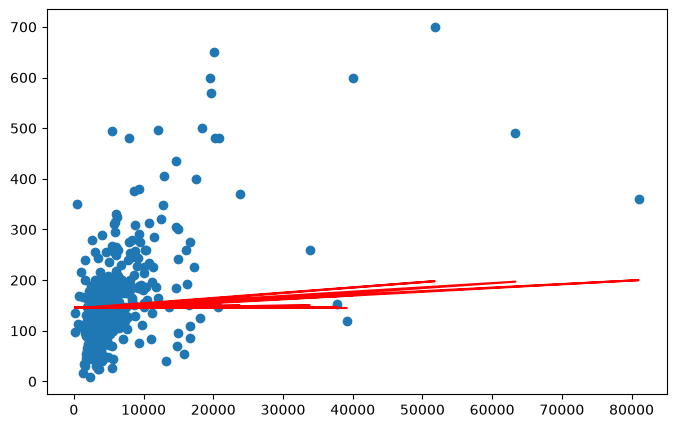

In [64]:
plt.figure(figsize=(8,5))
plt.scatter(X,Y)
plt.plot(X,Y_pred,color = "red")
plt.title = ("simple Linear chart")
plt.xlabel=("Applicant Income")
plt.ylabel=("Loan Amount")
plt.show()

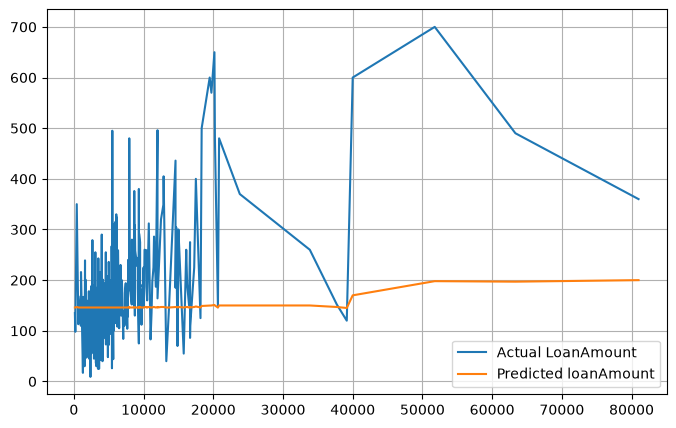

In [66]:
import matplotlib.pyplot as plt
sorted_data = pd.DataFrame({
    "X":X,
    "Actual" : Y,
    "Predicted":Y_pred
}).sort_values("X")
plt.figure(figsize=(8,5))
plt.plot(sorted_data["X"],sorted_data["Actual"],label="Actual LoanAmount")
plt.plot(sorted_data["X"],sorted_data["Predicted"],label="Predicted loanAmount")
plt.title = ("Actual vs Predicted LoanAmount")
plt.xlabel = ("Applicant Income")
plt.ylabel = ("Loan Amount")
plt.legend()
plt.grid(True)
plt.show()

Intercept(b0):  105.27724168234005
Slope(b1):  0.007881588870439892

Regression Equation:
LoanAmount = 105.27724168234005 + 0.007881588870439892 * ApplicantIncome
   ApplicantIncome  Actual LoanAmount  Predicted LoanAmount
0             9083              228.0                   177
1             4310              130.0                   139
2             4167              158.0                   138
3             2900               71.0                   128
4             2718               70.0                   127
5             1782              107.0                   119
6             3717              120.0                   135
7             3000               66.0                   129
8             2647              173.0                   126
9             1000              110.0                   113


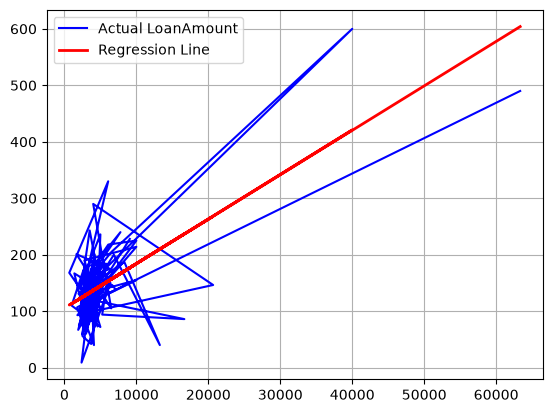

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression   
df=pd.read_csv(r'preprocessed_data_1.csv')
df.head()

X = df[['ApplicantIncome']]
y = df['LoanAmount']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
print("Intercept(b0): ", model.intercept_)
print("Slope(b1): ", model.coef_[0])
print("\nRegression Equation:")
print(f"LoanAmount = {model.intercept_} + {model.coef_[0]} * ApplicantIncome")
y_pred=model.predict(X_test)
y_pred = np.round(y_pred).astype(int)
result=pd.DataFrame({"ApplicantIncome": X_test["ApplicantIncome"].values,
                    "Actual LoanAmount": y_test.values,
                    "Predicted LoanAmount": y_pred})
print(result.head(10))
plot_data = pd.DataFrame({
    "ApplicantIncome": X_test["ApplicantIncome"].values,
    "Actual LoanAmount": y_test.values,
    "Predicted LoanAmount": y_pred})
plt.plot(
    plot_data["ApplicantIncome"],
    plot_data["Actual LoanAmount"],
    color="blue",
    label="Actual LoanAmount"
)
plt.plot(
    plot_data["ApplicantIncome"],
    plot_data["Predicted LoanAmount"],
    color="red",
    linewidth=2,
    label="Regression Line"
)
plt.title = ("Linear Regression using scikit-learn")
plt.xlabel = ("ApplicantIncome")
plt.ylabel = ("LoanAmount")
plt.legend()
plt.grid(True)
plt.show()